# 第3章 数学回顾

## 3.5 随机变量的数字特征

In [1]:
* 以数据集grilic.dta为例，打开此数据集，查看所包含的变量：
use data/grilic.dta,clear
describe


Contains data from data/grilic.dta
 Observations:           758                  
    Variables:            11                  30 Jan 2024 14:16
-------------------------------------------------------------------------------
Variable      Storage   Display    Value
    name         type    format    label      Variable label
-------------------------------------------------------------------------------
rns             byte    %8.0g                 south = 1
mrt             byte    %8.0g                 married = 1
smsa            byte    %8.0g                 big cities =1
med             byte    %8.0g                 mother's education
iq              int     %8.0g                 IQ
kww             byte    %8.0g                 KWW
age             byte    %8.0g                 age
s               byte    %8.0g                 schooling
expr            float   %9.0g                 experience
tenure          byte    %8.0g                 tenure
lnw             float   %9.0g        

In [2]:
* 看各变量的基本统计指标
sum


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
         rns |        758    .2691293    .4438001          0          1
         mrt |        758    .5145119    .5001194          0          1
        smsa |        758    .7044855     .456575          0          1
         med |        758    10.91029     2.74112          0         18
          iq |        758    103.8562    13.61867         54        145
-------------+---------------------------------------------------------
         kww |        758    36.57388    7.302247         12         56
         age |        758    21.83509    2.981756         16         30
           s |        758    13.40501    2.231828          9         18
        expr |        758    1.735429    2.105542          0     11.444
      tenure |        758    1.831135     1.67363          0         10
-------------+-------------------------------------------------

In [3]:
* 如想看lnw的更多统计指标，可加选择项 detail
sum lnw,detail


                          ln(wage)
-------------------------------------------------------------
      Percentiles      Smallest
 1%        4.804          4.605
 5%        5.011          4.605
10%        5.165          4.654       Obs                 758
25%         5.38          4.718       Sum of wgt.         758

50%        5.684                      Mean           5.686739
                        Largest       Std. dev.      .4289494
75%        5.991          6.786
90%        6.252          6.844       Variance       .1839976
95%        6.399          6.869       Skewness       .1744968
99%        6.706          7.051       Kurtosis        2.73237


(bin=25, start=4.605, width=.1)


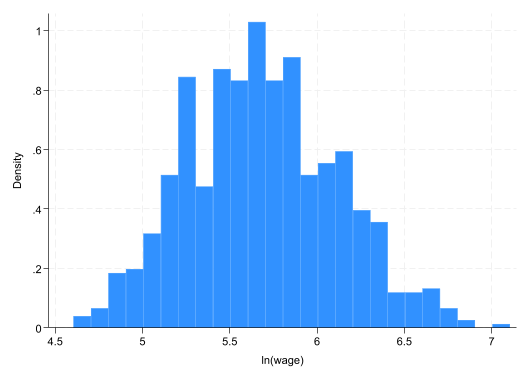

In [4]:
* 通过画lnw的直方图来看其(无条件)分布
hist lnw,width(0.1)

如想得到概率密度函数的连续估计，可输入命令：

- “kdensity”表示核密度估计(kernel density estimation)。
- 选择项“normal”表示画正态分布的密度函数作为对比。
- 选择项“normop(lpattern(dash))”则指示将正态密度用虚线(dash)来画(其中，normop表示normal options;而 lpattern表示line pattern)。

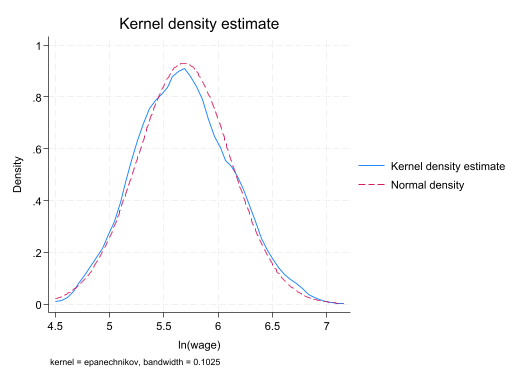

In [5]:
kdensity lnw,normal normop(lpattern(dash)) 

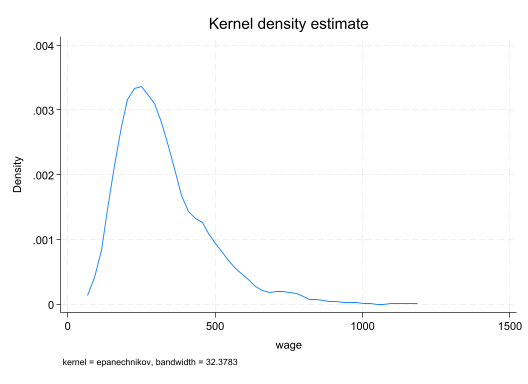

In [6]:
* 作为对比，考察工资水平本身的分布：
gen wage=exp(lnw)
kdensity wage

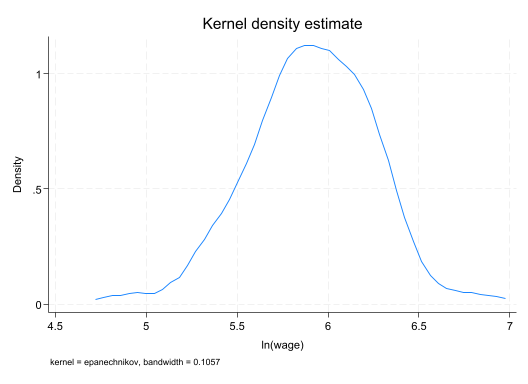

In [7]:
* 给定教育年限为16年(大学毕业)，工资对数的条件密度：
kdensity lnw if s==16

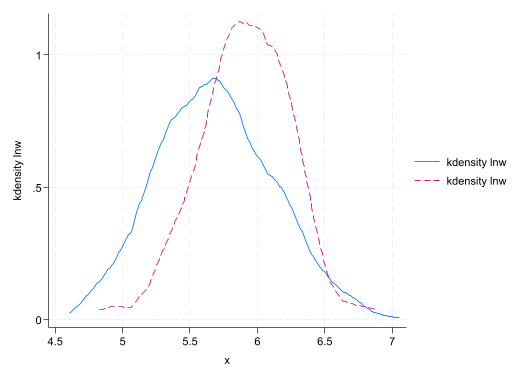

In [8]:
* 将lnw的无条件密度与条件密度画在一起：
twoway kdensity lnw || kdensity lnw if s==16,lpattern(dash)

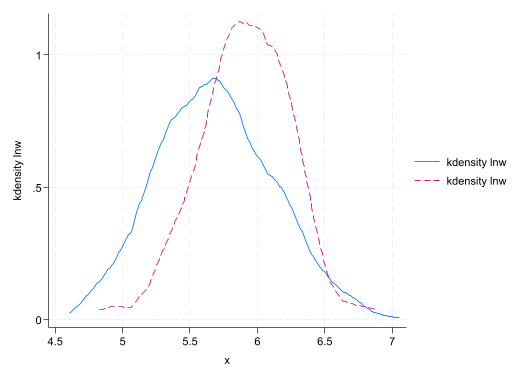

In [9]:
* 分隔符“||”的作用，也可以通过两个括号“( ) ( )”来等价地实现，比如：
twoway (kdensity lnw) (kdensity lnw if s==16,lpattern(dash))

In [10]:
* 比较lnw的无条件期望、方差与条件期望、条件方差：
sum lnw
sum lnw if s==16


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
         lnw |        758    5.686739    .4289494      4.605      7.051

    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
         lnw |        151    5.907338    .3396442      4.828      6.869


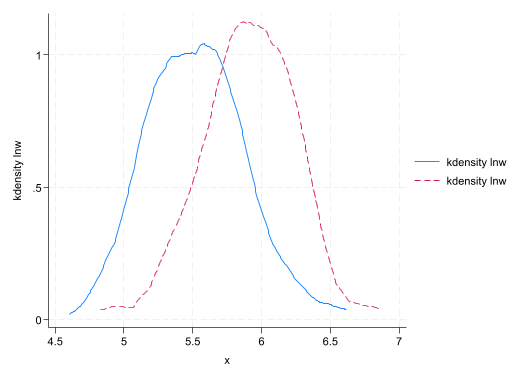

In [11]:
* 比较在s=12(中学毕业)与s=16(大学毕业)情况下，lnw的条件 密度：
twoway (kdensity lnw if s==12) (kdensity lnw if s==16,lpattern(dash))

## 3.6 迭代期望定律

In [12]:
use data/grilic.dta,clear
* rns为美国南方居民的虚拟变量，取值为0或1
* 首先，计算在rns=0的情况下，lnw的条件期望
* 结果显示：北方居民有554位，其条件期望为5.725644
sum lnw if rns==0


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
         lnw |        554    5.725644    .4129207      4.605      7.051


In [13]:
* 其次，计算在rns=1的情况下，lnw的条件期望
* 结果显示：南方居民有204位，其条件期望为5.581083
sum lnw if rns==1


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
         lnw |        204    5.581083    .4542189      4.718      6.844


In [14]:
* 将北方与南方居民的平均工资对数进行加权平均
dis 5.725644*(554/(554+204))+5.581083*(204/(554+204))

5.6867384


In [15]:
* 最后，计算无条件期望
* 显然，二者结果完全相等，从而验证了迭代期望定律
sum lnw


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
         lnw |        758    5.686739    .4289494      4.605      7.051


## 3.8 常用连续型统计分布

### 1. 正态分布

In [16]:
* 计算标准正态变量小于1.96的概率：
dis normal(1.96)

.9750021


如要画标准正态的密度函数，可输入命令：

- 选择项“range(-5 5)”表示在横轴区间(-5, 5)上画此图；默认为“range(0 1)”，即在(0, 1)区间画图。
- “xline(0)”表示在横轴x=0处画一条直线。
- “ytitle(概率密度)”表示将纵轴标签设为“概率密度”。

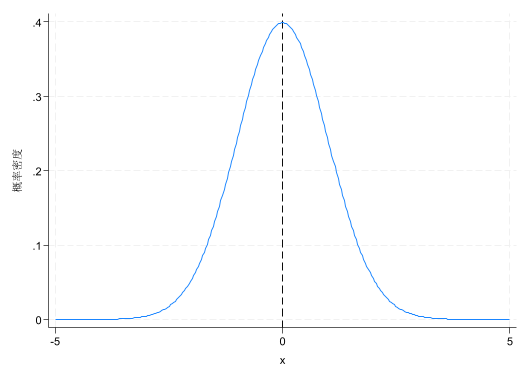

In [17]:
twoway function y=normalden(x),range(-5 5) xline(0) ytitle(概率密度)

正态分布$N(m,s^2)$的密度函数可用normalden(x,m,s)来表示，其中m与s分别为期望与标准差。

如下将N(0,1)与N(1,4)的密度函数画在一起：

- 选择项“lpattern(dash)”表示使用虚线画图。

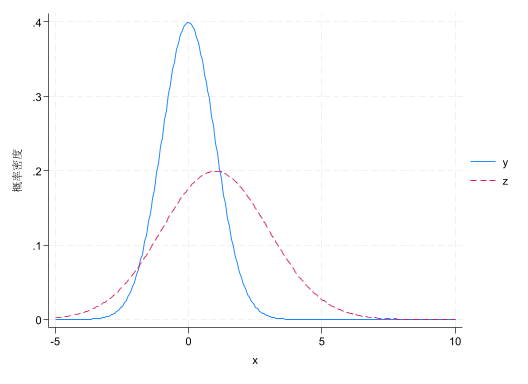

In [18]:
twoway function y=normalden(x),range(-5 10) || function z=normalden(x,1,2),range(-5 10) lpattern(dash) ytitle(概率密度)

### 2. $\chi^2$分布(卡方分布，Chi-square)

在Stata中，使用函数chi2den(k,x)与chi2(k,x)分别
表示自由度为k的卡方分布的概率密度与累积分布函数。比如，输入命令将$\chi^2(3)$与$\chi^2(5)$的密度函数画在一起：

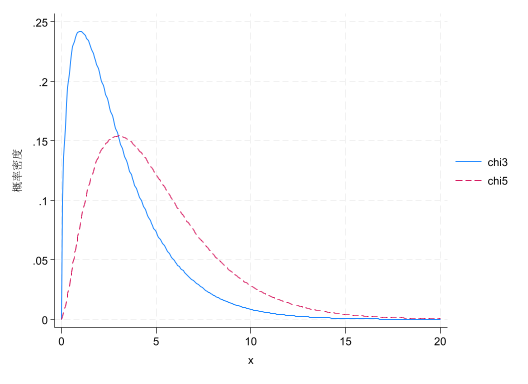

In [19]:
twoway function chi3=chi2den(3,x),range(0 20) || function chi5=chi2den(5,x),range(0 20) lpattern(dash) ytitle(概率密度)

### 3. t分布

在Stata中，使用函数tden(k,t)与t(k,t)分别表示自由度为 k的t分布的概率密度与累积分布函数。比如，使用命令将t(1)与t(5)的密度函数画在一起：

Stata以函数ttail(k,t)表示自由度为k的t分布的右侧尾部概率，即P(T>t)，正好是反向的累积分布函数。

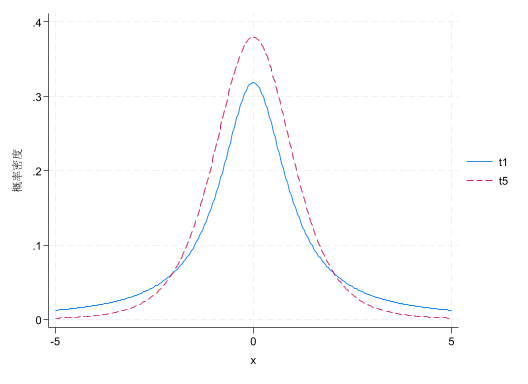

In [20]:
twoway function t1=tden(1,x),range(-5 5) || function t5=tden(5,x),range(-5 5) lpattern(dash) ytitle(概率密度)

### 4. F分布

Stata使用函数Fden(k1,k2,x)与F(k1,k2,x)分别表示自由度为(k1,k2)的F分布的概率密度与累积分布函数。比如，输入命令将F(10,20)与F(10,5)的密度函数画在一起：

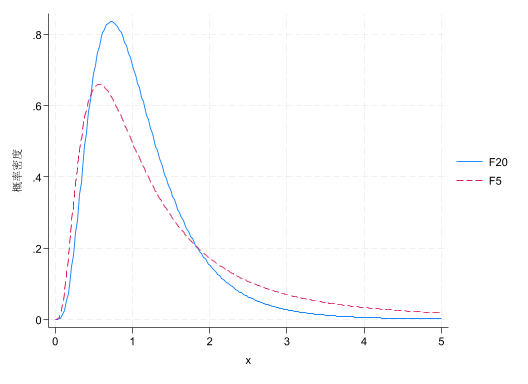

In [21]:
twoway function F20=Fden(10,20,x),range(0 5) || function F5=Fden(10,5,x),range(0 5) lpattern(dash) ytitle(概率密度)